In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Impor Data Training dan Testing

Langkah ini bertujuan untuk mengimpor dua dataset: `data_training.csv` dan `data_testing.csv`. `data_training.csv` akan digunakan untuk melatih model, sedangkan `data_testing.csv` akan digunakan untuk menguji performa model yang sudah terlatih.

In [4]:
#Import Data
from google.colab import files
uploaded = files.upload()

Saving data_training.csv to data_training.csv


In [5]:
from google.colab import files
uploaded = files.upload()

Saving data_testing.csv to data_testing.csv


In [6]:
train = pd.read_csv('data_training.csv')
test = pd.read_csv('data_testing.csv')

In [7]:
train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [8]:
test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


### Memeriksa Informasi Dataset

Pada langkah ini, kita akan melihat informasi dasar mengenai setiap kolom dalam dataset `train` dan `test`, termasuk tipe data dan jumlah nilai non-null. Ini membantu dalam mengidentifikasi adanya missing value atau tipe data yang tidak sesuai.

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [10]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB


Cek Missing Value

In [11]:
train.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [12]:
test.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


### Statistik Deskriptif Data Training

Bagian ini akan menampilkan ringkasan statistik deskriptif untuk dataset `train`, seperti mean, standar deviasi, nilai minimum, dan nilai maksimum. Ini memberikan gambaran awal tentang distribusi data dan potensi outlier.

Cek Data Duplikat

In [13]:
train.duplicated().sum()

np.int64(0)

In [14]:
test.duplicated().sum()

np.int64(0)

In [15]:
train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


### Pemisahan Fitur dan Target

Pada tahap ini, dataset `train` dibagi menjadi fitur (X) dan variabel target (y). Fitur adalah kolom-kolom yang akan digunakan untuk memprediksi, sedangkan target adalah kolom yang ingin kita prediksi (`quality`). Kolom `Id` juga dihapus dari fitur karena bukan merupakan variabel prediktif.

Berdasarkan hasil eksplorasi data, tidak ditemukan missing value pada dataset. Seluruh variabel memiliki jumlah data yang sama. Namun, terdapat perbedaan skala antar fitur sehingga diperlukan proses normalisasi menggunakan StandardScaler sebelum dilakukan pemodelan.

In [16]:
X = train.drop(['quality', 'Id'], axis=1)
y = train['quality']

### Pembagian Data Latih dan Validasi

Data fitur (X) dan target (y) dibagi lagi menjadi set pelatihan (training set) dan set validasi (validation set). Set pelatihan digunakan untuk melatih model, sementara set validasi digunakan untuk mengevaluasi performa model secara independen dan menyetel hyperparameter, guna menghindari overfitting pada data pelatihan.

In [17]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0


In [18]:
y.head()

,quality
0,5
1,5
2,7
3,6
4,6


In [19]:
#Split Data
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (685, 11)
X_val: (172, 11)
y_train: (685,)
y_val: (172,)


### Implementasi Logistic Regression

Bagian ini memulai implementasi model klasifikasi Logistic Regression. Ini adalah model linear yang digunakan untuk memprediksi probabilitas kelas target. Tahap-tahapnya meliputi inisialisasi model, pelatihan pada data `X_train_scaled`, dan prediksi pada `X_val_scaled`.

Data dipisahkan menjadi data latih dan data validasi dengan perbandingan 80:20 menggunakan metode train_test_split. Pemisahan ini bertujuan untuk mengevaluasi performa model sebelum digunakan pada data uji.

Scaling Data

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [22]:
X_train_scaled = scaler.fit_transform(X_train)

In [23]:
X_val_scaled = scaler.transform(X_val)

In [24]:
print(X_train_scaled[:5])

[[-0.80699355 -0.24191336 -0.38083773 -0.62789314 -0.1721627  -0.27598118
  -0.62533275 -0.64952368  0.45473736 -0.10029819 -0.59570451]
 [ 0.72575201  0.19316547  0.02306991 -0.1680498  -0.11324608  0.67091143
   3.09358322  0.60563315 -0.26768432 -0.61174432 -0.98369953]
 [-0.6301383  -0.02437394 -0.68376845 -0.39797147 -0.58457911  0.19746512
  -0.7513977  -0.51065526 -0.66173251  0.1270112  -0.49870576]
 [ 0.489945    0.79139887 -0.78474536  0.21515298  0.10278156 -0.4653597
  -0.05804049  1.171789   -0.00498552 -0.61174432 -0.88670078]
 [-1.04280056 -0.02437394 -1.03718763 -0.39797147 -0.48638473  1.23904699
  -0.05804049 -0.95930707  0.45473736  0.97942141 -0.11071074]]


Dilakukan normalisasi data menggunakan StandardScaler untuk menyamakan skala antar fitur. Proses fitting dilakukan pada data training, kemudian digunakan untuk mentransformasi data validasi guna menghindari data leakage.

Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
logistic_model = LogisticRegression(max_iter=1000)

In [27]:
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [28]:
pred_logreg = logistic_model.predict(X_val_scaled)

In [29]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, pred_logreg) * 100

59.883720930232556

### Visualisasi Confusion Matrix untuk Logistic Regression

Confusion Matrix adalah alat visual untuk mengevaluasi performa model klasifikasi. Ini menunjukkan jumlah prediksi benar dan salah untuk setiap kelas. Dengan visualisasi ini, kita bisa melihat di mana model melakukan kesalahan prediksi.

In [30]:
x_val_df = pd.DataFrame(X_val, columns=X.columns)

x_val_df['Prediksi'] = pred_logreg
x_val_df['Actual'] = y_val.values

x_val_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Prediksi,Actual
712,6.8,0.59,0.06,6.0,0.060,11.0,18.0,0.99620,3.41,0.59,10.8,6,7
603,7.2,0.54,0.27,2.6,0.084,12.0,78.0,0.99640,3.39,0.71,11.0,6,5
120,8.2,0.74,0.09,2.0,0.067,5.0,10.0,0.99418,3.28,0.57,11.8,6,6
208,10.8,0.50,0.46,2.5,0.073,5.0,27.0,1.00010,3.05,0.64,9.5,5,5
380,9.9,0.59,0.07,3.4,0.102,32.0,71.0,1.00015,3.31,0.71,9.8,5,5


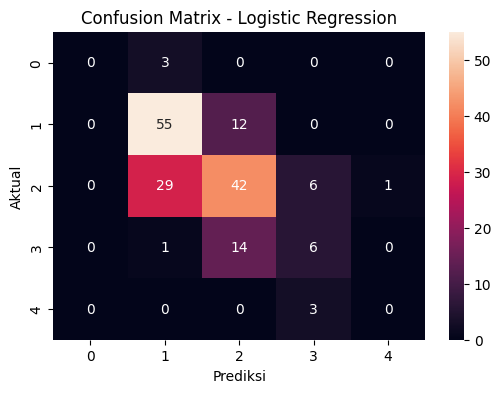

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, pred_logreg)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_logreg))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.62      0.82      0.71        67
           6       0.62      0.54      0.58        78
           7       0.40      0.29      0.33        21
           8       0.00      0.00      0.00         3

    accuracy                           0.60       172
   macro avg       0.33      0.33      0.32       172
weighted avg       0.57      0.60      0.58       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Implementasi K-Nearest Neighbors (KNN)

Bagian ini mengimplementasikan model klasifikasi KNN. KNN adalah algoritma berbasis instans yang mengklasifikasikan titik data baru berdasarkan mayoritas kelas dari tetangga terdekatnya. Tahap-tahapnya meliputi inisialisasi model, pelatihan, dan prediksi.

KNN

In [33]:
from sklearn.neighbors import KNeighborsClassifier

In [34]:
knn = KNeighborsClassifier(n_neighbors=5)

In [35]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [36]:
pred_knn = knn.predict(X_val_scaled)

In [37]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, pred_knn) * 100

49.41860465116279

### Visualisasi Confusion Matrix untuk KNN

Sama seperti Logistic Regression, Confusion Matrix untuk KNN memberikan gambaran performa model dalam mengklasifikasikan setiap kelas, membantu kita memahami jenis kesalahan yang dibuat.

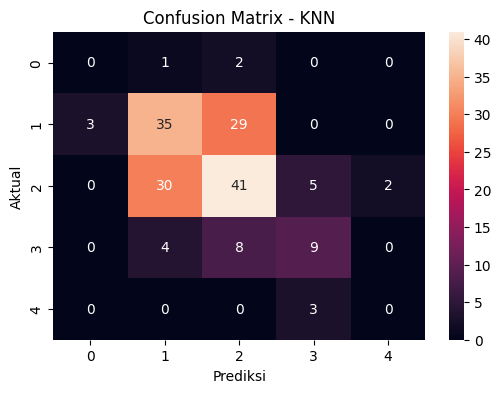

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_val, pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_knn))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.50      0.52      0.51        67
           6       0.51      0.53      0.52        78
           7       0.53      0.43      0.47        21
           8       0.00      0.00      0.00         3

    accuracy                           0.49       172
   macro avg       0.31      0.30      0.30       172
weighted avg       0.49      0.49      0.49       172



### Optimalisasi Nilai K pada KNN

Bagian ini melakukan pencarian untuk menemukan nilai `k` (jumlah tetangga terdekat) yang optimal untuk model KNN. Dengan menguji berbagai nilai `k` dan memplot akurasinya, kita dapat mengidentifikasi nilai `k` yang menghasilkan performa terbaik pada data validasi.

In [40]:
akurasi_k = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_val_scaled)
    acc = accuracy_score(y_val, pred)
    akurasi_k.append(acc)

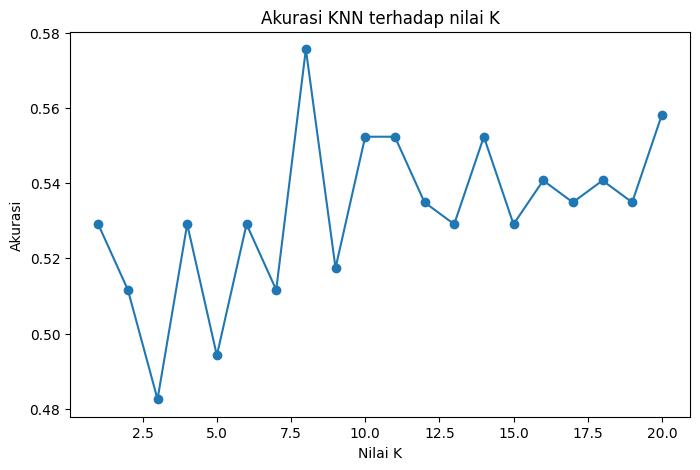

In [41]:
plt.figure(figsize=(8,5))
plt.plot(range(1,21), akurasi_k, marker='o')
plt.title('Akurasi KNN terhadap nilai K')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.show()

In [42]:
best_k = akurasi_k.index(max(akurasi_k)) + 1
print("K terbaik:", best_k)

K terbaik: 8


### Implementasi Decision Tree

Bagian ini mengimplementasikan model klasifikasi Decision Tree. Decision Tree adalah model non-linear yang membuat keputusan berdasarkan serangkaian aturan if-else. Tahap-tahapnya meliputi inisialisasi model, pelatihan, dan prediksi.

In [43]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

pred_knn_best = knn_best.predict(X_val_scaled)

accuracy_score(y_val, pred_knn_best) * 100

57.55813953488372

Decision Tree

In [44]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
dt = DecisionTreeClassifier(random_state=42)

In [46]:
dt.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [47]:
pred_dt = dt.predict(X_val_scaled)

In [48]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, pred_dt) * 100

46.51162790697674

### Visualisasi Confusion Matrix untuk Decision Tree

Confusion Matrix untuk Decision Tree membantu mengevaluasi seberapa baik model ini dalam memprediksi setiap kelas 'quality' dan mengidentifikasi area kesalahan.

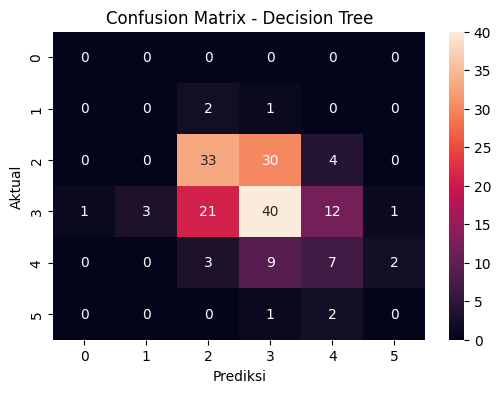

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_val, pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_dt))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         3
           5       0.56      0.49      0.52        67
           6       0.49      0.51      0.50        78
           7       0.28      0.33      0.30        21
           8       0.00      0.00      0.00         3

    accuracy                           0.47       172
   macro avg       0.22      0.22      0.22       172
weighted avg       0.48      0.47      0.47       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


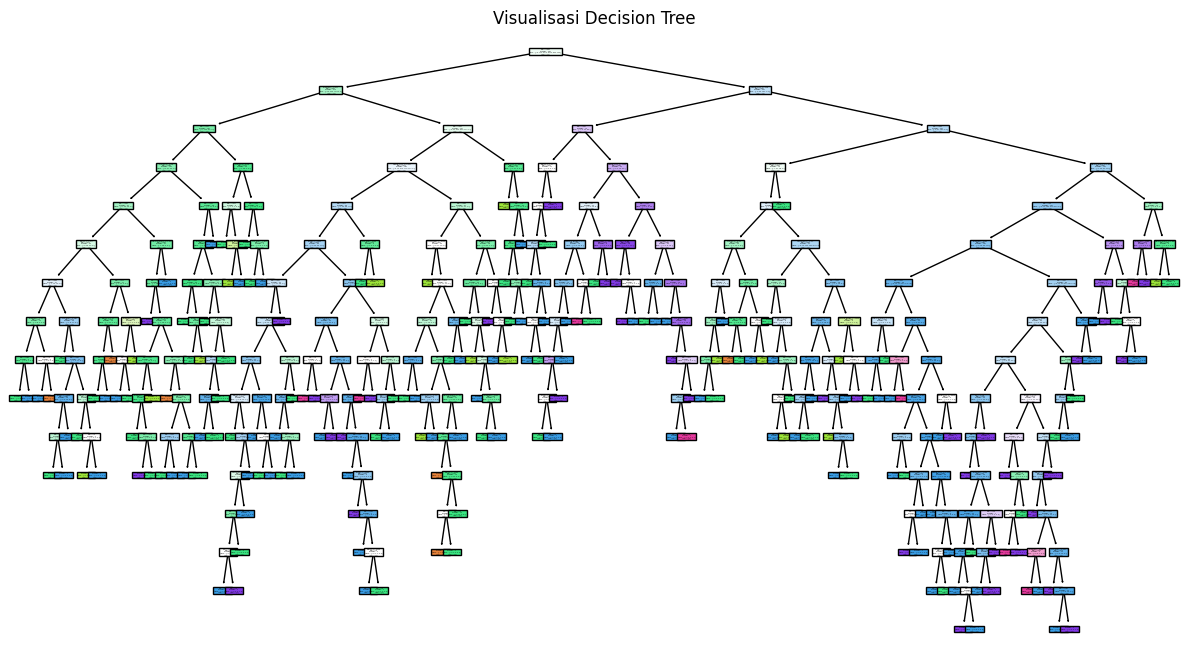

In [51]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True)
plt.title("Visualisasi Decision Tree")
plt.show()

### Tuning Hyperparameter Decision Tree

Setelah mengevaluasi Decision Tree default, langkah ini mencoba melakukan tuning hyperparameter, seperti `max_depth`, untuk meningkatkan performanya. Dengan membatasi kedalaman pohon, kita bisa mengurangi overfitting.

In [52]:
dt_tuned = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_tuned.fit(X_train_scaled, y_train)

pred_dt_tuned = dt_tuned.predict(X_val_scaled)

accuracy_score(y_val, pred_dt_tuned) * 100

56.395348837209305

In [53]:
print("Default:", accuracy_score(y_val, pred_dt))
print("Tuned:", accuracy_score(y_val, pred_dt_tuned))

Default: 0.46511627906976744
Tuned: 0.563953488372093


### Implementasi Random Forest

Bagian ini mengimplementasikan model klasifikasi Random Forest. Random Forest adalah metode ensemble yang membangun banyak Decision Tree dan menggabungkan prediksi mereka untuk menghasilkan prediksi akhir. Ini sering kali memberikan performa yang lebih baik daripada satu Decision Tree tunggal.

Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
rf = RandomForestClassifier(random_state=42)

In [56]:
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [57]:
pred_rf = rf.predict(X_val_scaled)

In [58]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, pred_rf) * 100

58.139534883720934

### Visualisasi Confusion Matrix untuk Random Forest

Confusion Matrix untuk Random Forest memberikan gambaran performa agregat dari ensemble Decision Tree dalam mengklasifikasikan 'quality'.

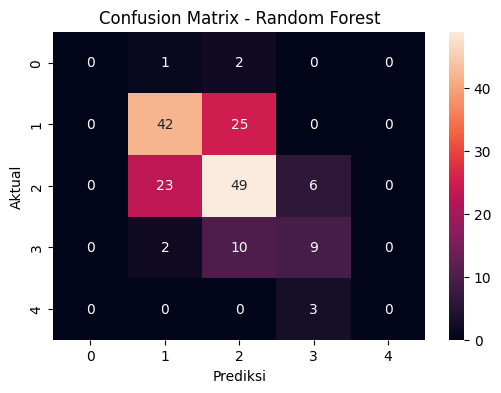

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_val, pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_rf))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.62      0.63      0.62        67
           6       0.57      0.63      0.60        78
           7       0.50      0.43      0.46        21
           8       0.00      0.00      0.00         3

    accuracy                           0.58       172
   macro avg       0.34      0.34      0.34       172
weighted avg       0.56      0.58      0.57       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Analisis Feature Importance Random Forest

Salah satu keunggulan Random Forest adalah kemampuannya untuk mengukur pentingnya (importance) setiap fitur dalam membuat prediksi. Bagian ini menghitung dan memvisualisasikan fitur-fitur yang paling berpengaruh pada model.

In [61]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Fitur,Importance
10,alcohol,0.138230
9,sulphates,0.122101
1,volatile acidity,0.111581
6,total sulfur dioxide,0.103166
7,density,0.085063
8,pH,0.079332
4,chlorides,0.076376
0,fixed acidity,0.074998
2,citric acid,0.074906
3,residual sugar,0.068532


### Tuning Hyperparameter Random Forest

Setelah mengevaluasi Random Forest default, langkah ini mencoba melakukan tuning hyperparameter seperti `n_estimators` (jumlah pohon) dan `max_depth` (kedalaman maksimum pohon) untuk meningkatkan performanya.

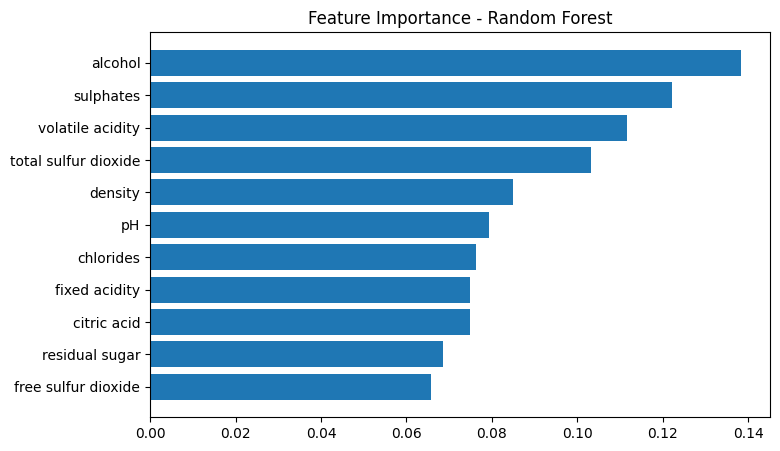

In [62]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Fitur'], feature_importance['Importance'])
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [63]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_tuned.fit(X_train_scaled, y_train)

pred_rf_tuned = rf_tuned.predict(X_val_scaled)

accuracy_score(y_val, pred_rf_tuned) * 100

59.30232558139535

In [64]:
print("Default:", accuracy_score(y_val, pred_rf))
print("Tuned:", accuracy_score(y_val, pred_rf_tuned))

Default: 0.5813953488372093
Tuned: 0.5930232558139535


### Hyperparameter Tuning Lanjutan (GridSearchCV)  Logistic Regression


In [66]:
from sklearn.linear_model import LogisticRegression

# Definisikan parameter grid yang akan dicari
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'max_iter': [1000]
}

# Inisialisasi LogisticRegression
lr = LogisticRegression(random_state=42)

# Inisialisasi GridSearchCV
grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, cv=5, n_jobs=-1, verbose=2)

# Lakukan pencarian grid pada data training yang sudah di-scaling
grid_search_lr.fit(X_train_scaled, y_train)

# Cetak hyperparameter terbaik
print(f"Best parameters for Logistic Regression: {grid_search_lr.best_params_}")

# Dapatkan model terbaik
best_lr_model = grid_search_lr.best_estimator_

# Prediksi pada data validasi menggunakan model terbaik
pred_lr_grid = best_lr_model.predict(X_val_scaled)

# Evaluasi akurasi
accuracy_lr_grid = accuracy_score(y_val, pred_lr_grid) * 100
print(f"Accuracy of Tuned Logistic Regression with GridSearchCV: {accuracy_lr_grid:.2f}%")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters for Logistic Regression: {'C': 10, 'max_iter': 1000, 'solver': 'saga'}
Accuracy of Tuned Logistic Regression with GridSearchCV: 59.88%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Hyperparameter Tuning (GridSearchCV) Random Forest


In [72]:
from sklearn.model_selection import GridSearchCV

# Definisikan parameter grid yang akan dicari
param_grid = {
    'n_estimators': [100, 200, 300], # Jumlah pohon dalam forest
    'max_depth': [None, 10, 20, 30], # Kedalaman maksimum pohon
    'min_samples_split': [2, 5, 10], # Jumlah minimum sampel yang dibutuhkan untuk membagi node internal
    'min_samples_leaf': [1, 2, 4] # Jumlah minimum sampel yang dibutuhkan di node leaf
}

# Inisialisasi RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Inisialisasi GridSearchCV
# cv=5 berarti 5-fold cross-validation
# n_jobs=-1 akan menggunakan semua core CPU yang tersedia
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Lakukan pencarian grid pada data training yang sudah di-scaling
grid_search.fit(X_train_scaled, y_train)

# Cetak hyperparameter terbaik
print(f"Best parameters found: {grid_search.best_params_}")

# Dapatkan model terbaik
best_rf_model = grid_search.best_estimator_

# Prediksi pada data validasi menggunakan model terbaik
pred_rf_grid = best_rf_model.predict(X_val_scaled)

# Evaluasi akurasi
accuracy_rf_grid = accuracy_score(y_val, pred_rf_grid) * 100
print(f"Accuracy of Tuned Random Forest with GridSearchCV: {accuracy_rf_grid:.2f}%")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy of Tuned Random Forest with GridSearchCV: 62.21%


### Hyperparameter Tuning Lanjutan (GridSearchCV) untuk KNN

In [67]:
from sklearn.neighbors import KNeighborsClassifier

# Definisikan parameter grid yang akan dicari
param_grid_knn = {
    'n_neighbors': list(range(1, 31)), # Jumlah tetangga
    'weights': ['uniform', 'distance'], # Pembobotan tetangga
    'metric': ['euclidean', 'manhattan'] # Metrik jarak
}

# Inisialisasi KNeighborsClassifier
knn = KNeighborsClassifier()

# Inisialisasi GridSearchCV
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=5, n_jobs=-1, verbose=2)

# Lakukan pencarian grid pada data training yang sudah di-scaling
grid_search_knn.fit(X_train_scaled, y_train)

# Cetak hyperparameter terbaik
print(f"Best parameters for KNN: {grid_search_knn.best_params_}")

# Dapatkan model terbaik
best_knn_model = grid_search_knn.best_estimator_

# Prediksi pada data validasi menggunakan model terbaik
pred_knn_grid = best_knn_model.predict(X_val_scaled)

# Evaluasi akurasi
accuracy_knn_grid = accuracy_score(y_val, pred_knn_grid) * 100
print(f"Accuracy of Tuned KNN with GridSearchCV: {accuracy_knn_grid:.2f}%")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}
Accuracy of Tuned KNN with GridSearchCV: 58.72%


### Evaluasi Model Terbaik


In [74]:
X_test = test.drop('Id', axis=1) # Asumsi 'Id' adalah satu-satunya kolom yang perlu dihapus dari test set

# Scaling data uji menggunakan scaler yang sama yang digunakan pada data latih
X_test_scaled = scaler.transform(X_test)

# Prediksi menggunakan model Random Forest terbaik (best_rf_model dari GridSearchCV)
final_predictions = best_rf_model.predict(X_test_scaled)

# Tampilkan beberapa hasil prediksi
print("Prediksi Kualitas untuk Data Uji:")
print(final_predictions[:10])

Prediksi Kualitas untuk Data Uji:
[5 5 5 5 5 6 5 5 6 5]


### Kesimpulan
Model Random Forest Classifier yang di-tuning dengan GridSearchCV mencapai akurasi terbaik sebesar 62.21% pada data validasi. Meskipun percobaan penanganan ketidakseimbangan kelas menggunakan SMOTE meningkatkan recall untuk beberapa kelas minoritas, hal tersebut justru menurunkan akurasi keseluruhan menjadi 59.30%, dan kelas yang sangat jarang (seperti kualitas 8) masih sulit diprediksi dengan baik. Akurasi 62.21% ini memberikan indikasi performa model yang solid dalam memprediksi kualitas anggur.

### Menyimpan Hasil Prediksi ke CSV

Setelah model terbaik digunakan untuk membuat prediksi pada data uji, langkah ini adalah menyimpan hasil prediksi tersebut ke dalam file CSV. File ini berisi `Id` dari setiap sampel data uji dan prediksi `Quality` yang sesuai.

In [78]:
from google.colab import files
files.download('hasilprediksi_098.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'Quality': final_predictions
})

submission.to_csv('hasilprediksi_098.csv', index=False)

print("Prediksi berhasil disimpan ke hasilprediksi_098.csv")

Prediksi berhasil disimpan ke hasilprediksi_098.csv


In [77]:
# Tampilkan 5 baris pertama dari file CSV yang baru dibuat
sub = pd.read_csv('hasilprediksi_098.csv')
display(sub.head())

,Id,Quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,5


In [75]:
#Import Data
from google.colab import files
uploaded = files.upload()

Saving hasilprediksi_098.csv to hasilprediksi_098.csv
